In [1]:
import json
import gzip
import os
import pickle
from collections import defaultdict
from experiments_vllm import *
from config_eplb import *
from trace_analysis import *

In [2]:
# Analyze all traces
print('\n... EPLB Run ...')
trace_results_eplb = summarize(trace_path_eplb)

print('\n... No EPLB Run ...')
trace_results_noeplb = summarize(trace_path_noeplb)


... EPLB Run ...
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp3_dcp0_ep3_rank3.1787688686364892749.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp7_dcp0_ep7_rank7.1787688687293180822.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp6_dcp0_ep6_rank6.1787688687475996189.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp4_dcp0_ep4_rank4.1787688690018417008.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp5_dcp0_ep5_rank5.1787688717229137209.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_eplb_gpu8_batch16_samples100_runs1/dp0_pp0_tp0_dcp0_ep0_rank0.1787688715479683625.pt.trace.json.gz
reading directory: ./vllm_benchmarking/traces/deepseek_epl

In [6]:
def plot_kernel_hist(results_balanced, results_imbalanced):
    plt.figure(figsize=(8, 5))
    plt.style.use('seaborn-v0_8-whitegrid')

    calls = results_balanced['calls_per_rank']
    durs_balanced = sum(results_balanced['per_rank_durs'], [])
    durs_imbalanced = sum(results_imbalanced['per_rank_durs'], [])
    durs_total = durs_balanced + durs_imbalanced

    total_dur_balanced = results_balanced['total_over_ranks_ms']
    total_dur_imbalanced = results_imbalanced['total_over_ranks_ms']
    
    # Create uniform bins
    n_bins = 1000
    bin_width = (max(durs_total) - min(durs_total)) / n_bins
    bins = np.arange(min(durs_total), max(durs_total) + bin_width, bin_width)
    
    # Hist for each
    plt.hist(durs_balanced, bins=bins,
                  label=f'baseline model (total time: {total_dur_balanced:.2f}ms, max: {max(durs_balanced):.2f}us)', color="#4C72B0")
    plt.hist(durs_imbalanced, bins=bins,
                  label=f'imbalanced model (total time: {total_dur_imbalanced:.2f}ms, max: {max(durs_imbalanced):.2f}us)', color="#C44E52")

    #plt.xlim((0,250))
    plt.title(f'MoE Kernel Times vs. Forced Imbalance\nTotal Calls: {calls}')
    plt.xlabel('Kernel Time (us)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

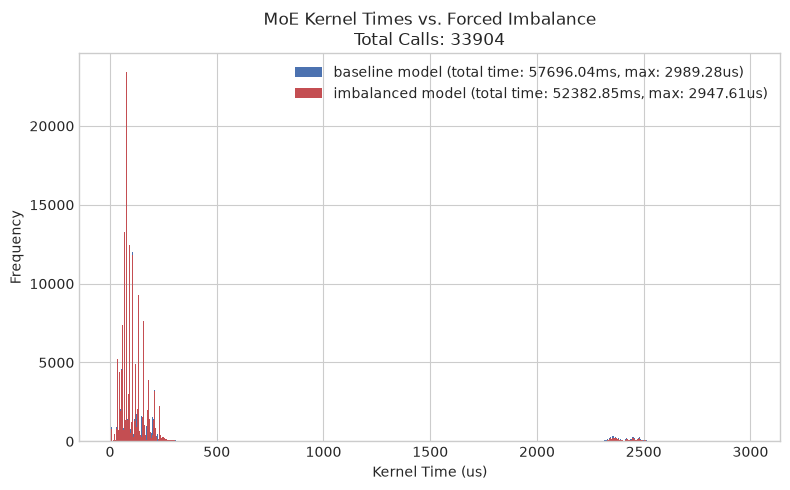

In [7]:
plot_kernel_hist(trace_results_eplb, trace_results_noeplb)

In [ ]:
trace_results_eplb

In [ ]:
trace_results_noeplb